# Phase 5 — Predictive Modeling (XGBoost)

**Mục tiêu:** dùng GraphSAGE embeddings làm features để dự đoán xác suất **next inspection Fail** trong 365 ngày.

**Models:**
- **XGBoost** (primary) — gradient boosting, `scale_pos_weight` cho imbalance
- **MLP** (comparator) — small neural net trên embedding dày

**Metrics:** Accuracy, ROC-AUC, F1, PR-AUC + Confusion Matrix  
**Split:** chronological train ≤ 2016-12-31 / val ≤ 2017-12-31 / test ≤ 2018-09-30  
**Selection:** validation PR-AUC chọn model; validation F1 chọn decision threshold; test chỉ evaluate một lần.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

REPO = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

from food_safety_gnn.prediction import (
    ClassifierConfig,
    TemporalSplitConfig,
    assign_temporal_split,
    export_prediction_artifacts,
    join_embeddings,
    train_classifiers,
)
from food_safety_gnn.viz import apply_project_style, SERIES, CRITICAL

apply_project_style()
CFG = yaml.safe_load((REPO / 'configs' / 'phase5' / 'classifier_v1.yaml').read_text(encoding='utf-8'))
PHASE3 = REPO / CFG['inputs']['phase3_directory']
EMB_PATH = REPO / CFG['inputs']['embeddings_path']
OUT = REPO / CFG['output_directory']
print('labels dir:', PHASE3)
print('embeddings:', EMB_PATH.exists(), EMB_PATH)
print('xgboost import ok')


labels dir: /home/jkl/Code/BTL-MH/data/interim/phase3/v1
embeddings: True /home/jkl/Code/BTL-MH/artifacts/phase4/v1/entity_embeddings.parquet
xgboost import ok


## 1. Load labels + embeddings, assign temporal split

In [2]:
labels = pd.read_parquet(PHASE3 / 'eligible_next_inspection_labels.parquet')
embeddings = pd.read_parquet(EMB_PATH)
print('labels:', len(labels), 'embeddings:', len(embeddings))

split_cfg = TemporalSplitConfig(**CFG['temporal_split'])
split_labels = assign_temporal_split(labels, split_cfg)
dataset = join_embeddings(split_labels, embeddings)
print(dataset['split'].value_counts().to_dict())
print('positive rate overall:', float(dataset['target_label'].mean()))
dataset[['entity_id', 'Inspection Date', 'split', 'target_label']].head()


labels: 113226 embeddings: 8000


{'train': 21760, 'validation': 2695, 'test': 1364}
positive rate overall: 0.18377938727293852


,entity_id,Inspection Date,split,target_label
0,000ba072340e694fc94d,2011-05-10,train,0
1,0012813c934629a11b64,2013-05-20,train,0
2,002b75827a89fe0265b9,2012-09-25,train,0
3,002ea7011e87f9a1a5be,2015-08-27,train,0
4,00300d2f4935bedff3a2,2014-07-08,train,0


## 2. Train XGBoost + MLP (validation model selection)

In [3]:
clf_raw = CFG['classifier']
clf_cfg = ClassifierConfig(
    random_state=clf_raw['random_state'],
    xgb_n_estimators=clf_raw['xgb_n_estimators'],
    xgb_max_depth=clf_raw['xgb_max_depth'],
    xgb_learning_rate=clf_raw['xgb_learning_rate'],
    xgb_subsample=clf_raw['xgb_subsample'],
    xgb_colsample_bytree=clf_raw['xgb_colsample_bytree'],
    xgb_min_child_weight=clf_raw['xgb_min_child_weight'],
    mlp_hidden_layer_sizes=tuple(clf_raw['mlp_hidden_layer_sizes']),
    mlp_max_iter=clf_raw['mlp_max_iter'],
)
results = train_classifiers(dataset, clf_cfg)
print('selected model:', results['selected_model'])
print('split counts:', json.dumps(results['split_counts'], indent=2))
for name, payload in results['models'].items():
    print(f'\n=== {name} ===')
    print('validation:', json.dumps(payload['validation'], indent=2))
    if 'test' in payload:
        print('test:', json.dumps(payload['test'], indent=2))


selected model: mlp
split counts: {
  "train": 21760,
  "validation": 2695,
  "test": 1364,
  "train_positive_rate": 0.18143382352941176,
  "validation_positive_rate": 0.19925788497217067,
  "test_positive_rate": 0.1906158357771261,
  "scale_pos_weight": 4.511651469098277
}

=== xgboost ===
validation: {
  "accuracy": 0.3758812615955473,
  "roc_auc": 0.5747459110183752,
  "pr_auc": 0.24995971638406198,
  "f1": 0.3424550430023456,
  "precision": 0.21672439386442355,
  "recall": 0.8156424581005587,
  "support": 2695,
  "positive_rate": 0.19925788497217067,
  "decision_threshold": 0.20590142160654068
}

=== mlp ===
validation: {
  "accuracy": 0.4775510204081633,
  "roc_auc": 0.5797651284122307,
  "pr_auc": 0.25282099584023254,
  "f1": 0.3463324048282266,
  "precision": 0.23067408781694496,
  "recall": 0.6945996275605214,
  "support": 2695,
  "positive_rate": 0.19925788497217067,
  "decision_threshold": 0.12144918739795685
}
test: {
  "accuracy": 0.436950146627566,
  "roc_auc": 0.537491290

## 3. Metric comparison chart

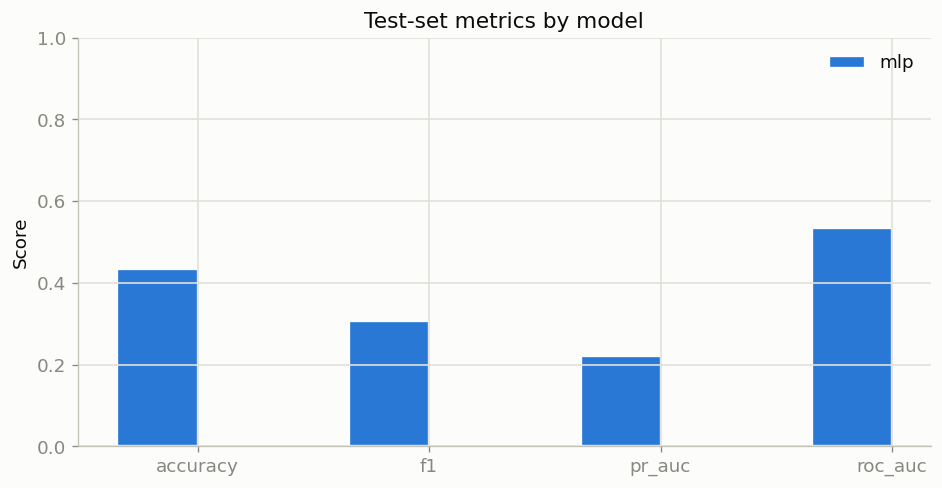

model,mlp
metric,
accuracy,0.436950
f1,0.308108
pr_auc,0.223602
roc_auc,0.537491


In [4]:
rows = []
for name, payload in results['models'].items():
    for split_name in ('validation', 'test'):
        if split_name not in payload:
            continue
        metrics = payload[split_name]
        for metric_name in ('accuracy', 'roc_auc', 'f1', 'pr_auc'):
            rows.append({
                'model': name,
                'split': split_name,
                'metric': metric_name,
                'value': metrics[metric_name],
            })
metrics_df = pd.DataFrame(rows)
test_metrics = metrics_df[metrics_df['split'] == 'test']
pivot = test_metrics.pivot(index='metric', columns='model', values='value')

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(pivot.index))
width = 0.35
for i, model in enumerate(pivot.columns):
    ax.bar(
        x + (i - 0.5) * width,
        pivot[model].values,
        width=width,
        label=model,
        color=SERIES[i],
        edgecolor='#fcfcfb',
        linewidth=2,
    )
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.tolist())
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Test-set metrics by model')
ax.legend()
fig.tight_layout()
plt.show()
pivot


## 4. Confusion matrix (selected model, test set)

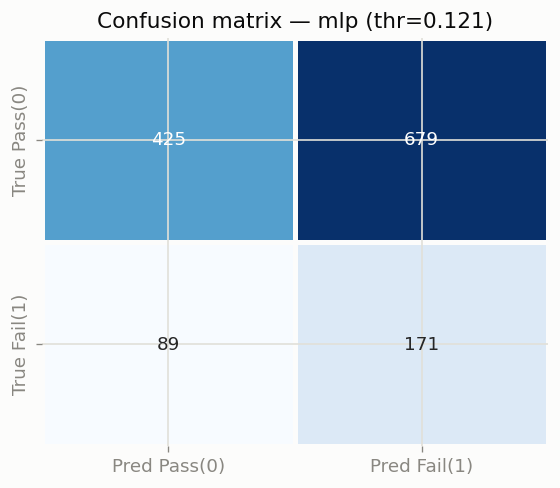

{'labels': [0, 1], 'matrix': [[425, 679], [89, 171]], 'tn': 425, 'fp': 679, 'fn': 89, 'tp': 171, 'decision_threshold': 0.12144918739795685}


In [5]:
cm = np.array(results['confusion_matrix']['matrix'])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred Pass(0)', 'Pred Fail(1)'],
    yticklabels=['True Pass(0)', 'True Fail(1)'],
    ax=ax,
    linewidths=2,
    linecolor='#fcfcfb',
)
ax.set_title(
    f"Confusion matrix — {results['selected_model']} "
    f"(thr={results['confusion_matrix']['decision_threshold']:.3f})"
)
fig.tight_layout()
plt.show()
print(results['confusion_matrix'])


## 5. Probability distribution on test set

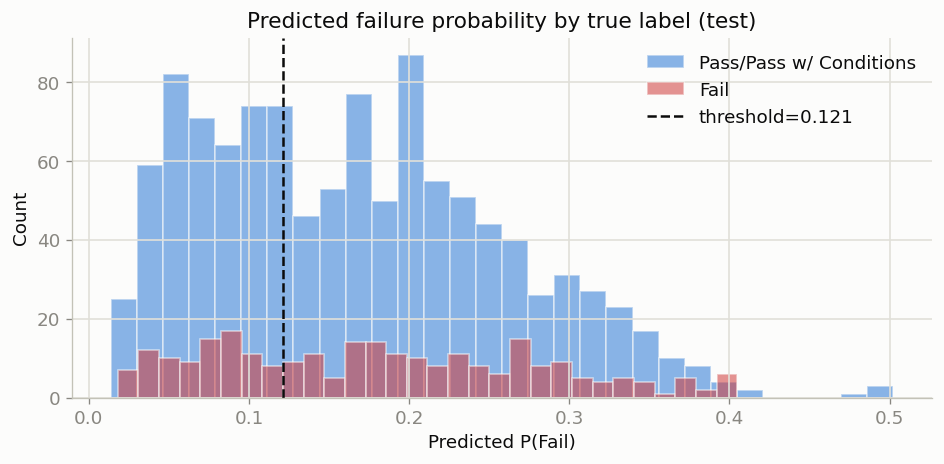

,entity_id,Inspection Date,target_label,probability,prediction,model,decision_threshold
0,009bbe5fe07cea8ca85f,2018-01-29,0,0.284543,1,mlp,0.121449
1,00a5665e7d2738e35700,2018-06-15,0,0.063926,0,mlp,0.121449
2,00a998fcacfb1bcd4846,2018-05-31,0,0.324296,1,mlp,0.121449
3,010597a20cdb2aa1f91c,2018-06-12,0,0.305868,1,mlp,0.121449
4,010597a20cdb2aa1f91c,2018-06-27,1,0.305868,1,mlp,0.121449


In [6]:
preds = results['test_predictions']
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, SERIES[0], 'Pass/Pass w/ Conditions'), (1, CRITICAL, 'Fail')]:
    subset = preds.loc[preds['target_label'] == label, 'probability']
    ax.hist(subset, bins=30, alpha=0.55, label=name, color=color, edgecolor='#fcfcfb')
thr = float(preds['decision_threshold'].iloc[0])
ax.axvline(thr, color='#0b0b0b', linestyle='--', linewidth=1.5, label=f'threshold={thr:.3f}')
ax.set_title('Predicted failure probability by true label (test)')
ax.set_xlabel('Predicted P(Fail)')
ax.set_ylabel('Count')
ax.legend()
fig.tight_layout()
plt.show()
preds.head()


## 6. Export artifacts

In [7]:
paths = export_prediction_artifacts(results, OUT)
print(json.dumps(paths, indent=2))
print('selected model test metrics:')
print(json.dumps(results['models'][results['selected_model']]['test'], indent=2))


{
  "predictions": "/home/jkl/Code/BTL-MH/artifacts/phase5/v1/test_predictions.parquet",
  "metrics": "/home/jkl/Code/BTL-MH/artifacts/phase5/v1/metrics.json"
}
selected model test metrics:
{
  "accuracy": 0.436950146627566,
  "roc_auc": 0.537491290412486,
  "pr_auc": 0.22360219865818837,
  "f1": 0.3081081081081081,
  "precision": 0.2011764705882353,
  "recall": 0.6576923076923077,
  "support": 1364,
  "positive_rate": 0.1906158357771261,
  "decision_threshold": 0.12144918739795685
}
